# ÉquiAlgo — modèle méthodologique et audit

## Résumé

Choix du 3 octobre 2026, à la demande de l'équipe : privilégier une règle explicable et une validation traçable, sans nouveau réglage sur le leaderboard dans cette phase.

**Règle retenue : cote R + 0.143426 × heures travaillées**, top 40 % (1 600 bourses sur 4 000). Poids appris sur l'historique après ajustement du revenu et du groupe régional; leurs contributions directes sont ensuite retirées du score. Modèle compact retenu dans les cinq plis de validation imbriquée. Intervalle bootstrap descriptif du poids : [0.1293; 0.1608].

**Limite centrale :** la neutralisation est un choix de politique, pas une correction causale identifiée. Les heures compensent une charge de travail par hypothèse normative; les organisateurs ne fournissent pas de formule de mérite. Les labels de mérite sont absents, donc aucun F1 caché ni point IVADO n'est annoncé. Les mesures de performance ci-dessous portent sur le comité historique.

L'ancien notebook est archivé lors de l'installation. Les diagnostics antérieurs restent dans `artifacts/equialgo/` et le registre des essais. Le nouveau CSV ne reprend pas le score de l'ancien fichier Q1650.

## Contexte et méthode

**Contraintes officielles :** 36–44 % d'octrois; 4 000 IDs; colonnes `id_candidat,decision_octroi`. Le jury note le diagnostic (25), la technique (35 : équité 20, utilité 15), la gouvernance (25) et la présentation/code (15). L'égalité des chances et l'utilité techniques utilisent le mérite indépendant non fourni. HxBuddy affiche un indicateur distinct.

**Hypothèses assumées :** cote R comme résultat académique; heures comme charge à compenser; effets directs du revenu et du lieu non retenus pour attribuer. Les choix de 40 % et de neutralisation complète ont été fixés avant les calculs de cette phase méthodologique ; les explorations antérieures étaient connues; aucun taux n'est ajusté aux retours HxBuddy. Les variables sont supposées disponibles au dépôt, sans horodatage permettant de l'attester.

**Validation :** cinq plis externes stratifiés région × décision; trois plis internes pour choisir parmi trois spécifications logistiques et trois niveaux de régularisation. La règle « une erreur standard » privilégie la plus simple des configurations proches du meilleur résultat interne. Prétraitement au train seulement. Les données ont déjà été explorées : validation de développement, pas test indépendant. Aucun nouveau label n'est inventé.

**Politique et probabilité :** la régression complète prédit le comité. Son score réduit, après retrait du contexte, sert uniquement au classement. Il n'est pas une probabilité de mérite. R et heures peuvent rester des proxys régionaux; l'invariance directe ne supprime pas toutes les inégalités.

**Quota canonique :** 36–44 % inclusifs, soit 1 440–1 760 bourses. Le choix 1 600 (40 %) et l’ancien choix 1 650 (41,25 %) sont tous deux autorisés. [Provenance et interface](docs/equialgo/01-probleme-et-regles.md).

In [1]:
from pathlib import Path
import json, sys, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd()
if not (ROOT / 'model_corrige.py').exists():
    ROOT = next(p for p in ROOT.parents if (p / 'model_corrige.py').exists())
sys.path.insert(0, str(ROOT))
import model_corrige as model_code
OUT = ROOT / 'artifacts/equialgo/methode_finale_20261003/resultats'
report = json.loads((OUT / 'rapport.json').read_text(encoding='utf-8'))
model = json.loads((OUT / 'modele.json').read_text(encoding='utf-8'))
historique = pd.read_csv(ROOT / 'data/equialgo/data/donnees_demandes.csv')
evaluation = pd.read_csv(ROOT / 'data/equialgo/data/candidats_evaluation.csv')
ACTIVE_CSV = ROOT / 'predictions.csv'
assert hashlib.sha256(ACTIVE_CSV.read_bytes()).hexdigest() == hashlib.sha256((OUT/'predictions_methodologiques.csv').read_bytes()).hexdigest()
predictions = pd.read_csv(ACTIVE_CSV)
print('CSV actif : predictions.csv — 4 000 demandes, politique à 40 %.')
plt.rcParams.update({'figure.figsize': (9, 4.5), 'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': False, 'figure.facecolor': 'white'})
BLEU, GRIS = '#285a89', '#686f75'


CSV actif : predictions.csv — 4 000 demandes, politique à 40 %.


## Données

10 000 demandes historiques; 4 000 candidats sans labels. Données synthétiques, institution fictive. Les identifiants ne sont pas des features. Les deux cohortes n'ont aucun ID commun; aucune imputation nécessaire. Les profils extrêmes sont conservés. Les contrôles de doublons ne prouvent pas l'absence de liens familiaux non fournis.

,demandes,octrois,cote_R_moyenne,heures_moyennes,taux_octroi_pct
groupe,,,,,
Centres,6000,2902,27.987,8.972,48.367
Régions éloignées,4000,1092,27.327,13.020,27.300


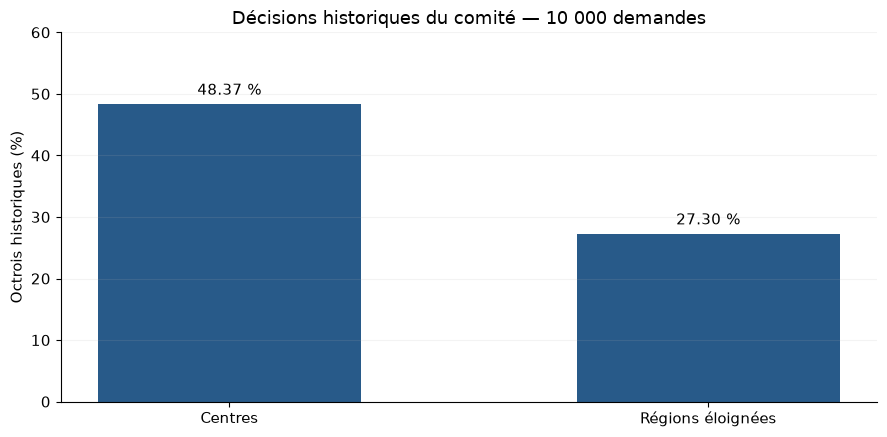

In [2]:
assert len(historique) == 10000 and len(evaluation) == 4000
assert historique.id_candidat.is_unique and evaluation.id_candidat.is_unique
assert not set(historique.id_candidat) & set(evaluation.id_candidat)
assert not historique.isna().any().any() and not evaluation.isna().any().any()
assert not historique.drop(columns=['id_candidat', 'decision_octroi']).duplicated().any()
historique['groupe'] = np.where(historique.region_administrative.isin(model_code.REMOTE), 'Régions éloignées', 'Centres')
diagnostic = historique.groupby('groupe').agg(demandes=('id_candidat', 'size'), octrois=('decision_octroi', 'sum'),
                                            cote_R_moyenne=('cote_r_equivalent', 'mean'), heures_moyennes=('heures_travail_semaine', 'mean'))
diagnostic['taux_octroi_pct'] = 100 * diagnostic.octrois / diagnostic.demandes
display(diagnostic.round(3))
fig, ax = plt.subplots()
bars = ax.bar(diagnostic.index, diagnostic.taux_octroi_pct, color=BLEU, width=.55)
ax.bar_label(bars, fmt='%.2f %%', padding=4)
ax.set(ylim=(0, 60), ylabel='Octrois historiques (%)', title='Décisions historiques du comité — 10 000 demandes')
ax.grid(axis='y', alpha=.15); fig.tight_layout(); fig.savefig(OUT/'diagnostic_historique.png', dpi=160); plt.show()


L'écart historique de sélection est une observation. Les différences de cote R et de contexte en expliquent potentiellement une partie; elles n'identifient pas des effets causaux. Le README indique que retirer seulement région/code postal laisse des proxys. Le modèle complet inclut donc le contexte à l'apprentissage; la règle finale neutralise sa contribution directe, avec la limite exposée ci-dessus.

### Rejeu du notebook officiel

Le notebook fourni a été exécuté sans modification des cellules, dans un dossier isolé. Sur son découpage 70/30 fixé par les organisateurs : accuracy historique 88,13 %, écart de sélection 18,76 points ; sans région 18,05 points ; sans région et code postal 17,31 points. Ces résultats montrent la persistance d'associations régionales après retrait des variables explicites. Ce découpage n'est pas celui de notre validation imbriquée : ne pas transformer les différences entre ces scores en gain statistique.

Preuves : `artifacts/equialgo/complements_20261003/baseline_officielle/baseline_model_execute.ipynb`, `sorties.txt` et `verification.json`. Le CSV de démonstration est isolé et n'est pas la soumission recommandée. Ce rejeu a été effectué après le développement ; il ne prouve pas qu'une exécution avait précédé toutes les modifications antérieures.

## Variables proxies : diagnostic quantitatif

Nous prédisons le **groupe régional**, jamais le mérite, à partir de chaque variable. Cinq plis stratifiés par région ; régression logistique fixée ; standardisation et catégories apprises sur le train de chaque pli. Les identifiants et les décisions historiques ne sont pas des entrées de ce diagnostic. Une cible permutée sert de contrôle de plausibilité.

L’AUC mesure ici une association géographique : le postal et la distance sont très informatifs, les heures le sont aussi. Cela ne prouve ni causalité ni illégitimité d’une variable. Le choix de conserver les heures comme compensation reste normatif. Les barres représentent le minimum et le maximum des cinq plis, pas un intervalle de confiance.

[Protocole](artifacts/equialgo/complements_20261003/proxies/PROTOCOLE.md) · [AUC détaillées](artifacts/equialgo/complements_20261003/proxies/auc_proxies.csv) · [Distributions](artifacts/equialgo/complements_20261003/proxies/distributions.csv).


,Variables,AUC moyenne,Minimum,Maximum
0,Cote R,0.561,0.542,0.584
1,Heures travaillées,0.805,0.794,0.818
2,Log du revenu,0.692,0.668,0.706
3,Distance au campus,0.998,0.997,0.999
4,Première génération,0.590,0.569,0.605
5,Code postal,1.000,1.000,1.000
6,Programme,0.553,0.538,0.570
7,Cote R + heures,0.810,0.799,0.824
8,Ensemble sans postal,0.999,0.997,1.000
9,Ensemble avec postal,1.000,1.000,1.000


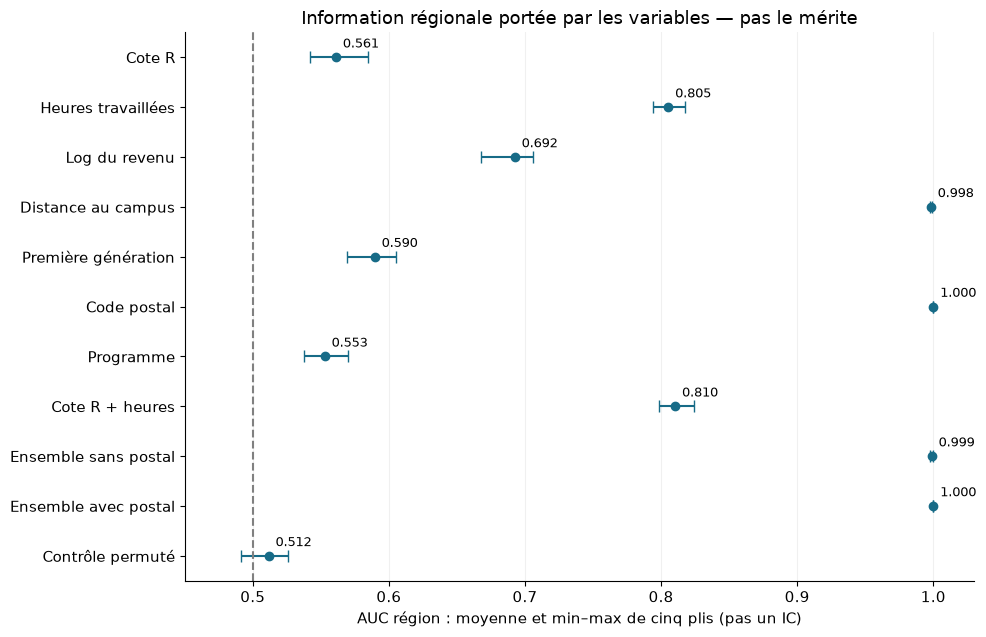

,Variable,Moyenne centres,Moyenne éloignés,Écart standardisé
0,cote_r_equivalent,27.987,27.327,-0.221
1,heures_travail_semaine,8.972,13.020,1.222
2,log_revenu,11.151,10.844,-0.719
3,distance_domicile_campus_km,19.792,221.455,2.585
4,premiere_generation_universitaire,0.265,0.444,0.381
5,revenu_familial_estime,76056.286,56330.325,-0.661


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
PROXY_ROOT = Path(ROOT) / "artifacts/equialgo/complements_20261003/proxies"
proxy_auc = pd.read_csv(PROXY_ROOT / "auc_proxies.csv")
display(proxy_auc[["label", "auc_mean", "auc_min", "auc_max"]].rename(columns={"label":"Variables", "auc_mean":"AUC moyenne", "auc_min":"Minimum", "auc_max":"Maximum"}).round(3))
proxy_plot = proxy_auc.iloc[::-1]
proxy_x = proxy_plot.auc_mean.to_numpy()
proxy_error = np.vstack([proxy_x-proxy_plot.auc_min, proxy_plot.auc_max-proxy_x])
fig, ax = plt.subplots(figsize=(10, 6.5))
ax.errorbar(proxy_x, np.arange(len(proxy_plot)), xerr=proxy_error, fmt="o", color="#176b87", capsize=4)
ax.set_yticks(np.arange(len(proxy_plot)), proxy_plot.label)
ax.axvline(.5, color="gray", linestyle="--")
ax.set_xlim(.45, 1.03)
ax.set_xlabel("AUC région : moyenne et min–max de cinq plis (pas un IC)")
ax.set_title("Information régionale portée par les variables — pas le mérite")
ax.grid(axis="x", alpha=.18)
for i, v in enumerate(proxy_x):
    ax.annotate(f"{v:.3f}", (v, i), xytext=(5, 7), textcoords="offset points", fontsize=9)
fig.tight_layout()
plt.show()
distributions = pd.read_csv(PROXY_ROOT / "distributions.csv")
display(distributions[['variable','mean_centre','mean_eloigne','smd_eloigne_moins_centre']].rename(columns={'variable':'Variable','mean_centre':'Moyenne centres','mean_eloigne':'Moyenne éloignés','smd_eloigne_moins_centre':'Écart standardisé'}).round(3))


,Groupe,Effectif,Octroi historique (%),Politique hors pli (%)
0,Centres,6000,48.37,40.30
1,Régions éloignées,4000,27.30,39.55


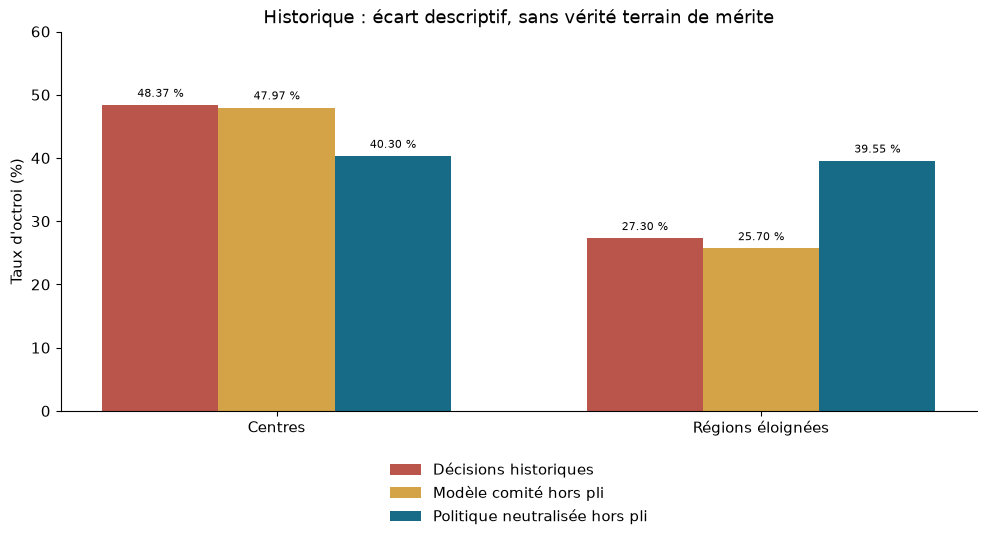

In [4]:
proxy_rates = pd.read_csv(PROXY_ROOT / "taux_octroi.csv")
taux = proxy_rates.loc[proxy_rates.level=='group', ['group','n','committee_rate','policy_oof_rate']].copy()
taux[['committee_rate','policy_oof_rate']] *= 100
display(taux.rename(columns={'group':'Groupe','n':'Effectif','committee_rate':'Octroi historique (%)','policy_oof_rate':'Politique hors pli (%)'}).round(2))
proxy_groups = proxy_rates.loc[proxy_rates.level=="group"].set_index("group").loc[["Centres", "Régions éloignées"]]
fig, ax = plt.subplots(figsize=(10, 5.6))
positions = np.arange(2)
for i, (column, label, color) in enumerate([
    ("committee_rate", "Décisions historiques", "#ba554b"),
    ("committee_model_oof_rate", "Modèle comité hors pli", "#d4a247"),
    ("policy_oof_rate", "Politique neutralisée hors pli", "#176b87"),
]):
    bars = ax.bar(positions+(i-1)*.24, proxy_groups[column]*100, .24, label=label, color=color)
    ax.bar_label(bars, fmt="%.2f %%", padding=4, fontsize=8)
ax.set_ylim(0, 60)
ax.set_xticks(positions, proxy_groups.index)
ax.set_ylabel("Taux d'octroi (%)")
ax.set_title("Historique : écart descriptif, sans vérité terrain de mérite")
ax.legend(loc="upper center", bbox_to_anchor=(.5, -.10), frameon=False)
fig.tight_layout()
plt.show()


## Résultats : comparer au même budget

Le modèle complet sert d’abord à expliquer le comité. Son F1 au seuil **0,5** mesure cet ajustement ; il sélectionne 39,06 % des historiques hors pli. Pour isoler le changement de règle, la comparaison principale utilise le **même budget de 40 % dans chaque pli**, soit 800 bénéficiaires sur 2 000. Les deux lignes de cette comparaison utilisent les mêmes personnes et les mêmes étiquettes historiques.

La politique neutralisée est moins conforme au comité. Cela ne démontre ni une amélioration ni une dégradation du mérite. Le notebook **rejoue et affiche des résultats figés** ; il ne réentraîne pas les modèles à chaque ouverture. Le réentraînement intégral est disponible dans le [guide](docs/equialgo/06-installation-reproduction.md).


In [5]:
plis = pd.read_csv(OUT / 'metriques_plis.csv')
table = plis[['fold','family','C','hours_weight','logloss']].copy()
table.columns = ['Pli','Modèle','C','Poids heures','Log-loss comité']
display(table.round(4))
comparaison = pd.read_csv(OUT/'neutralisation_plis.csv')
comparaison = comparaison[comparaison.neutralisation.isin([0,1])].groupby('neutralisation')[['accuracy_committee','f1_committee']].mean()*100
comparaison.index = ['Comité : top 40 %','Politique neutralisée : top 40 %']
comparaison.columns = ['Accuracy historique (%)','F1 macro historique (%)']
display(comparaison.round(3))
print('Diagnostic distinct, comité au seuil 0,5 : F1 = 88,1572 %, accuracy = 88,68 %.')


,Pli,Modèle,C,Poids heures,Log-loss comité
0,0,compact,0.1,0.1377,0.2738
1,1,compact,0.1,0.1444,0.2564
2,2,compact,0.1,0.1486,0.2620
3,3,compact,0.1,0.1374,0.2595
4,4,compact,0.1,0.1468,0.2472


,Accuracy historique (%),F1 macro historique (%)
Comité : top 40 %,88.76,88.289
Politique neutralisée : top 40 %,84.94,84.308


Diagnostic distinct, comité au seuil 0,5 : F1 = 88,1572 %, accuracy = 88,68 %.


### Stabilité du poids

Les 200 réplications bootstrap sont stratifiées région × décision, avec la configuration finale fixée. L'intervalle percentile reflète cette incertitude d'échantillonnage conditionnelle; il ne couvre pas toutes les décisions de sélection ni l'incertitude sur le mérite. Les modèles entraînés sans une région servent de contrôle de sensibilité des coefficients.

,excluded_region,hours_weight
0,Bas-Saint-Laurent,0.15274
1,Capitale-Nationale,0.14254
2,Cote-Nord,0.14601
3,Gaspesie-Iles-de-la-Madeleine,0.13779
4,Montreal,0.13459


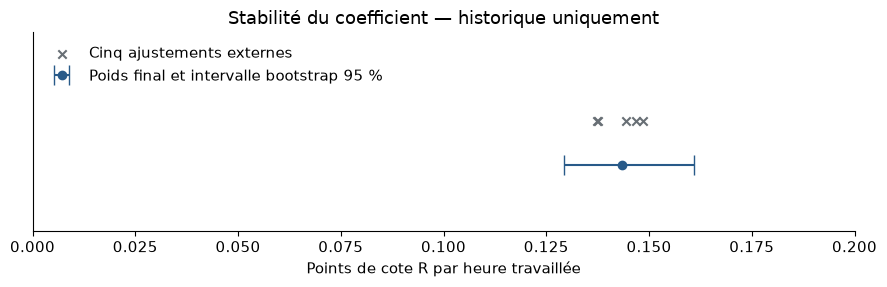

In [6]:
stabilite = pd.read_csv(OUT/'stabilite_regions.csv')
display(stabilite.round(5))
low, median, high = report['bootstrap_hours_weight_percentiles']
poids = float(model['hours_weight_decimal'])
fig, ax = plt.subplots(figsize=(9, 3))
ax.errorbar([poids], [0], xerr=[[poids-low], [high-poids]], fmt='o', color=BLEU, capsize=7, label='Poids final et intervalle bootstrap 95 %')
ax.scatter(plis.hours_weight, np.repeat(.2, len(plis)), color=GRIS, marker='x', label='Cinq ajustements externes')
ax.set(xlim=(0, .20), ylim=(-.3, .6), yticks=[], xlabel='Points de cote R par heure travaillée', title='Stabilité du coefficient — historique uniquement')
ax.legend(loc='upper left', frameon=False); fig.tight_layout(); fig.savefig(OUT/'stabilite_poids.png', dpi=160); plt.show()


## Incertitude de l’allocation

Les 200 poids bootstrap existants ont été appliqués aux mêmes 4 000 candidatures, à budget constant. **1 569 personnes sont retenues dans les 200 répétitions, 2 369 toujours refusées et 62 changent de statut dans au moins une répétition.** Le nombre de décisions différentes du CSV actuel est de 6 à la médiane, 24 au percentile 97,5 et 38 au maximum observé. Ce sont des résultats conditionnels à une spécification et une cohorte, **pas des probabilités de mérite ni des garanties de décision**.

Le CSV final atteint l’écart minimal réalisable à ce budget entier entre les deux groupes : `|651/1628 − 949/2372| = 0,000207167`, soit 0,0207 point. Cette propriété descriptive ne valide ni le budget de 40 % ni l’égalité des chances.

[Protocole du complément](artifacts/equialgo/remise_jury_20261003/PROTOCOLE-COMPLEMENTS.md) · [Résultats vérifiables](artifacts/equialgo/remise_jury_20261003/preuves_complementaires.json).


### Compromis observables et contraintes d'équité

Le graphique fait varier la neutralisation du contexte de 0 (score historique complet) à 1 (choix final). L'accord avec un comité biaisé peut baisser quand on retire ses effets de contexte. Les points résument les mêmes plis externes; ils ne déterminent pas le choix final. Cette courbe n'est pas le front officiel de mérite, non calculable ici.

,neutralisation,selection_gap_pct,accuracy_committee_pct
0,0.00,22.375,88.76
1,0.25,17.375,88.32
2,0.50,12.167,87.84
3,0.75,6.458,86.44
4,1.00,1.533,84.94


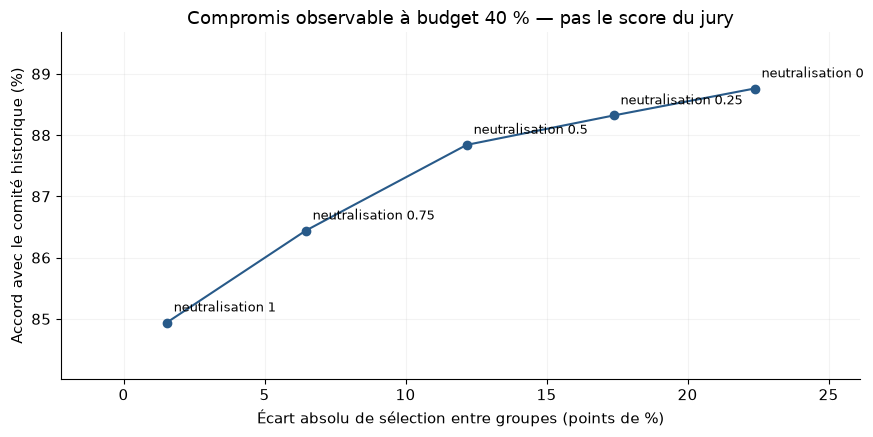

In [7]:
compromis = pd.read_csv(OUT/'neutralisation_plis.csv').groupby('neutralisation')[['selection_gap','accuracy_committee']].mean().reset_index()
display(compromis.assign(selection_gap_pct=100*compromis.selection_gap, accuracy_committee_pct=100*compromis.accuracy_committee)[['neutralisation','selection_gap_pct','accuracy_committee_pct']].round(3))
fig, ax = plt.subplots()
ax.plot(100*compromis.selection_gap, 100*compromis.accuracy_committee, 'o-', color=BLEU)
for _, row in compromis.iterrows():
    ax.annotate(f"neutralisation {row.neutralisation:g}", (100*row.selection_gap,100*row.accuracy_committee), xytext=(5,8), textcoords='offset points', fontsize=9)
ax.set(xlabel='Écart absolu de sélection entre groupes (points de %)', ylabel='Accord avec le comité historique (%)',
       title='Compromis observable à budget 40 % — pas le score du jury')
ax.margins(x=.18,y=.24); ax.grid(alpha=.15); fig.tight_layout(); fig.savefig(OUT/'compromis_neutralisation.png', dpi=160); plt.show()


La courbe précédente fait varier la quantité de contexte retirée, sans imposer une contrainte formelle. Le balayage explicite de contrainte ε est présenté plus bas. Les deux diagnostics restent fondés sur le comité historique, pas sur une vérité de mérite. [Mesures par pli](artifacts/equialgo/methode_finale_20261003/resultats/neutralisation_plis.csv).

In [8]:
display(pd.DataFrame(report['evaluation_region_rates']).assign(taux_pct=lambda d:100*d.selection_rate)[['region','n','grants','taux_pct']].rename(columns={'region':'Région','n':'Demandes','grants':'Bourses','taux_pct':'Octroi (%)'}).round(2))
print('TPR/FPR ci-dessous : référence = décisions du comité, jamais mérite indépendant.')
eq = pd.read_csv(OUT/'equite_historique_hors_pli.csv')
eq[['selection_rate','historical_tpr','historical_fpr']] *= 100
display(eq.rename(columns={'region':'Région','n':'Effectif','selection_rate':'Sélection (%)','historical_tpr':'TPR comité (%)','historical_fpr':'FPR comité (%)'}).round(2))
assert predictions.columns.tolist() == ['id_candidat','decision_octroi']
assert predictions.id_candidat.tolist() == evaluation.id_candidat.tolist()
assert predictions.id_candidat.is_unique and not predictions.isna().any().any()
assert set(predictions.decision_octroi) == {0,1} and predictions.decision_octroi.sum() == 1600
rejouees, _ = model_code.policy_decisions(evaluation, model)
assert np.array_equal(rejouees, predictions.decision_octroi)
assert hashlib.sha256((OUT/'predictions_methodologiques.csv').read_bytes()).hexdigest() == report['candidate_sha256']
print('Contrôlé : 4 000 IDs, 1 600 bourses, schéma, labels, relecture et reproduction des décisions.')


,Région,Demandes,Bourses,Octroi (%)
0,Bas-Saint-Laurent,504,193,38.29
1,Capitale-Nationale,821,326,39.71
2,Cote-Nord,491,195,39.71
3,Gaspesie-Iles-de-la-Madeleine,633,263,41.55
4,Montreal,1551,623,40.17


TPR/FPR ci-dessous : référence = décisions du comité, jamais mérite indépendant.


,Région,Effectif,Sélection (%),TPR comité (%),FPR comité (%)
0,Bas-Saint-Laurent,1293,38.75,94.54,18.20
1,Capitale-Nationale,1999,40.82,77.07,6.79
2,Cote-Nord,1178,39.30,92.58,20.28
3,Gaspesie-Iles-de-la-Madeleine,1529,40.42,93.78,19.27
4,Montreal,4001,40.04,76.27,6.14


Contrôlé : 4 000 IDs, 1 600 bourses, schéma, labels, relecture et reproduction des décisions.


## Front de Pareto observable : contrainte de parité explicite

Le cahier exige plusieurs réglages d’une contrainte d’équité. Nous fixons **ε = 0 ; 0,005 ; 0,01 ; 0,02 ; 0,05 ; 0,10 ; 0,15 ; 0,20 ; 0,25 ; sans contrainte**, avant le calcul. ε borne la différence absolue entre les taux de sélection des centres et des régions éloignées. Budget fixé à 40 % pour chaque cohorte. ε = 0,005 correspond à **0,5 point de pourcentage**, pas 0,005 point.

Dans chaque pli externe de 2 000 observations, on utilise les probabilités déjà produites hors pli par le modèle du comité. On énumère chaque nombre entier admissible de bourses régionales et on sélectionne les meilleurs scores de chaque groupe. L’allocation retenue maximise la somme des probabilités prédites, sous quota total et contrainte de parité. Les étiquettes du pli servent seulement à mesurer les résultats ; aucun seuil n’est ajusté pour optimiser ses étiquettes. Il s’agit d’une politique de sélection par cohorte utilisant ses groupes et scores, pas d’un seuil individuel estimé sur ces étiquettes.

**Les résultats sont des diagnostics contre les décisions biaisées du comité, pas contre le mérite.** L’accuracy mesure ici un accord historique ; le TPR signifie « proportion des anciens bénéficiaires sélectionnés ». Ni ce TPR ni sa différence régionale ne mesurent l’égalité des chances officielle. Aucun point de ce balayage n’est utilisé pour modifier la recommandation.

À ε = 0.005, l’écart moyen est **0.417 points**, l’accord historique **85.380 %** et le F1 macro **84.767 %**. Sans contrainte, l’écart est **22.375 points**, l’accord **88.760 %** et le F1 macro **88.289 %**. Les moyennes utilisent les cinq plis externes, avec exactement 800 bourses par pli. La parité exacte (ε = 0) est faisable dans trois plis seulement ; aucune moyenne sur ce sous-ensemble n’est présentée comme comparable aux cinq plis. Les barres représentent une erreur standard descriptive entre cinq plis dépendants ; elles n’estiment pas l’incertitude du mérite caché.

Le fichier `front_pareto_moyennes.csv` identifie séparément les points non dominés pour écart/accuracy, écart/F1 et écart/somme des scores. « Non dominé » est limité à cette grille et à ces métriques auxiliaires. Les seuils de contrainte et le modèle de score sont fixés ; cette analyse ne constitue pas une nouvelle sélection indépendante de modèle. Les métriques TPR/FPR par groupe et les comptes TP/FN/FP/TN figurent dans `contraintes_hors_pli.csv`.



,Contrainte (points),Plis faisables,Écart (points),Accord historique (%),F1 historique (%)
0,0,3,Non agrégé,Non agrégé,Non agrégé
1,0.5,5,0.417,85.38,84.77
2,1,5,0.875,85.56,84.95
3,2,5,1.875,85.9,85.31
4,5,5,4.958,86.66,86.1
5,10,5,9.958,87.72,87.2
6,15,5,14.958,88.28,87.79
7,20,5,19.958,88.7,88.23
8,25,5,22.375,88.76,88.29
9,Libre,5,22.375,88.76,88.29


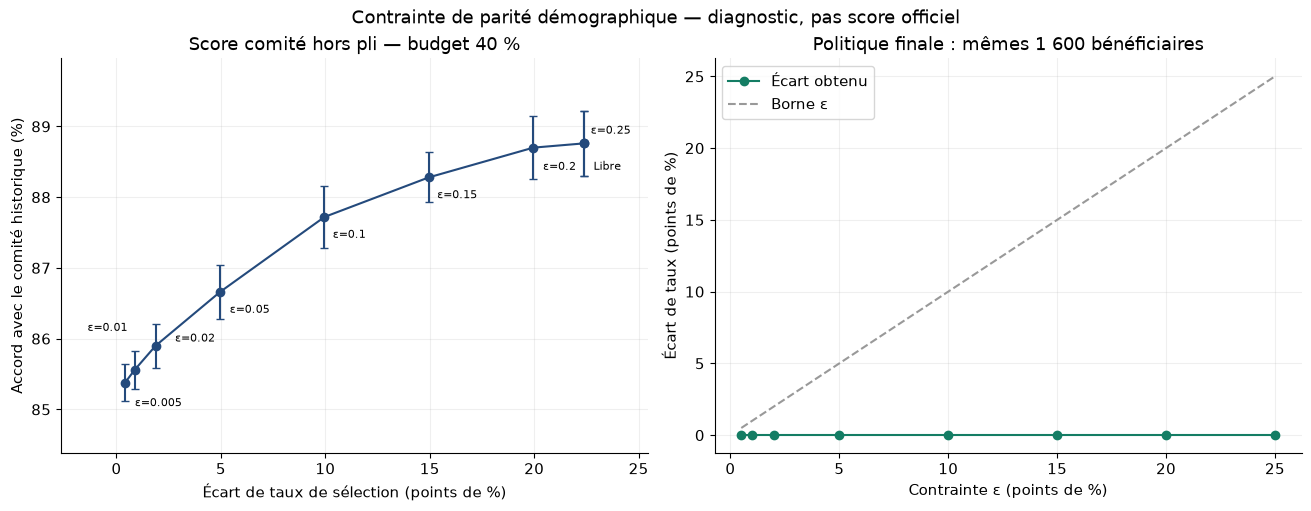

Politique finale : ε=0 infaisable ; pour tous les ε≥0,005 testés, mêmes 1 600 bénéficiaires. Écart = 0,0207 point.


In [9]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
pareto_dir = ROOT / 'artifacts/equialgo/complements_20261003/pareto'
pareto_moyennes = pd.read_csv(pareto_dir/'front_pareto_moyennes.csv')
pareto_final = pd.read_csv(pareto_dir/'contrainte_politique_finale.csv')
front_lisible = pd.DataFrame({'Contrainte (points)': pareto_moyennes.epsilon.map(lambda v:'Libre' if pd.isna(v) else f'{100*v:g}'),
    'Plis faisables':pareto_moyennes.feasible_folds,
    'Écart (points)':(100*pareto_moyennes.selection_gap).round(3),
    'Accord historique (%)':(100*pareto_moyennes.accuracy).round(2),
    'F1 historique (%)':(100*pareto_moyennes.f1_macro).round(2)})
display(front_lisible.astype(object).where(front_lisible.notna(), 'Non agrégé'))
pf = pareto_moyennes[pareto_moyennes['complete']]
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
axes[0].errorbar(pf.selection_gap*100, pf.accuracy*100,
                 yerr=pf.accuracy_se*100, fmt='o-', capsize=3, color='#244a7c')
label_offsets = [(7,-17),(-34,28),(14,3),(7,-15),(6,-15),(6,-15),(7,-16),(5,7),(7,-19)]
for (_, row), offset in zip(pf.iterrows(), label_offsets):
    label = 'Libre' if pd.isna(row.epsilon) else f'ε={row.epsilon:g}'
    axes[0].annotate(label, (row.selection_gap*100,row.accuracy*100),
                     xytext=offset,textcoords='offset points',fontsize=8)
axes[0].set(xlabel='Écart de taux de sélection (points de %)',
            ylabel='Accord avec le comité historique (%)', title='Score comité hors pli — budget 40 %')
axes[0].margins(x=.14,y=.18)
pf_eval = pareto_final[pareto_final.epsilon.notna() & (pareto_final.epsilon>0)]
axes[1].plot(pf_eval.epsilon*100, pf_eval.selection_gap*100, 'o-', color='#147d64', label='Écart obtenu')
axes[1].plot(pf_eval.epsilon*100, pf_eval.epsilon*100, '--', color='#999999', label='Borne ε')
axes[1].set(xlabel='Contrainte ε (points de %)',ylabel='Écart de taux (points de %)',
            title='Politique finale : mêmes 1 600 bénéficiaires')
axes[1].legend()
for ax in axes: ax.grid(alpha=.2)
fig.suptitle('Contrainte de parité démographique — diagnostic, pas score officiel')
plt.show()
print('Politique finale : ε=0 infaisable ; pour tous les ε≥0,005 testés, mêmes 1 600 bénéficiaires. Écart = 0,0207 point.')




La **politique finale neutralisée** est analysée séparément sur les 4 000 demandes sans étiquette. Sa parité démographique est presque spontanée : **0,0207 point**. Toutes les contraintes ε ≥ 0,005 sont non actives et redonnent exactement les mêmes 1 600 bénéficiaires. La parité exacte est infaisable pour ces effectifs entiers et ce budget. Il serait trompeur de dessiner plusieurs allocations distinctes pour ce modèle : son front observé se réduit à un point. Les points distincts de la figure de gauche proviennent donc explicitement du modèle reproduisant le comité, à des fins de diagnostic. Cette expérience démontre un compromis observable, pas le front officiel caché. La parité démographique est un indicateur accessible, alors que l’égalité des chances contre mérite est le critère du jury que nous ne pouvons mesurer.

**Limites et décision.** La contrainte utilise directement le groupe régional ; c’est un mécanisme de post-traitement étudié et non appliqué à `predictions.csv`. Aucun label de mérite n’est inventé. Une meilleure concordance avec le comité ne prouve pas une meilleure utilité réelle. Pour déployer une contrainte d’égalité des chances, il faudrait un échantillon de mérite indépendant et une politique approuvée, puis une nouvelle validation. Notre allocation neutralisée et son CSV restent inchangés.

Reproduction depuis la racine : `.\.venv\Scripts\python.exe artifacts/equialgo/complements_20261003/pareto/balayage.py`. Le protocole, les décisions de diagnostic et la vérification numérique sont archivés dans le même dossier.


## Décisions, gouvernance et limites

**Choix final :** régression compacte régularisée, neutralisation complète du contexte, budget 40 %, aucune contrainte de quota régional forcé. Sur cette cohorte, le classement est déjà presque paritaire entre les deux groupes officiels, sans avoir choisi le poids ou le budget pour obtenir cette parité. Les cinq régions ont des taux distincts, visibles dans le tableau; ne pas masquer ces différences avec le seul agrégat.

**Avant usage réel :** vérifier données et disponibilités, faire examiner les dossiers proches du seuil, fournir une explication de score et une voie de recours, documenter les exceptions autorisées. Une revue humaine est un mécanisme de gouvernance, pas une source de labels inventés dans ce challenge. Suivre dérive des caractéristiques, taux de sélection par région, volume de recours et modifications de politique. Quand une référence indépendante légitime devient disponible, mesurer TPR/FPR et utilité contre cette référence avec incertitude par groupe; décider des compromis avec les responsables du programme.

**Ce qui est établi :** reproductibilité, conformité du CSV, ajustement hors pli du comité, monotonie et invariance directe au contexte, stabilité descriptive du coefficient. **Ce qui ne l'est pas :** mérite réel, égalité des chances officielle, causalité de la correction, score sur 35 points et optimalité de 40 %.

**Reproduction du CSV :** `python model_corrige.py --model modele_equialgo.json --output predictions_reproduites.csv`. L'outil refuse l'écrasement d'un fichier existant. Pour réentraîner et revalider : `python model_corrige.py --train --output-dir artifacts/equialgo/reproduction_methodologique` (dossier neuf). Aucune soumission automatique.

**Livrables :** `predictions.csv`, `model_corrige.py`, `modele_equialgo.json`, ce notebook et `RAPPORT-METHODOLOGIQUE-EQUIALGO.md`. Le support `presentation.pdf` et le script minuté du pitch sont fournis séparément. Voir `README-EQUIALGO.md` et `CONFORMITE-EQUIALGO.md` pour la livraison.

**Sources :** [consignes](HxBuddy-Challenges/03-ivado-equialgo/equialgo-participants/consignes-fr.pdf), [README officiel](HxBuddy-Challenges/03-ivado-equialgo/equialgo-participants/README.md), [validation croisée scikit-learn](https://scikit-learn.org/stable/modules/cross_validation.html), [métriques Fairlearn et limites](https://fairlearn.org/main/user_guide/assessment/common_fairness_metrics.html). Les choix normatifs de ce document sont ceux de l'équipe, pas des prescriptions officielles.

## Gouvernance, surveillance et recours

Le plan détaillé est conservé dans `artifacts/equialgo/complements_20261003/presentation/plan_gouvernance.md`. Il s'agit d'une proposition pour un usage réel éventuel, avec des seuils à faire approuver. Les données du défi sont synthétiques et aucun déploiement n'a eu lieu.

| Contrôle | Fréquence | Responsable par rôle | Déclencheur proposé et suite |
|---|---|---|---|
| Format, données, budget et rejeu | Chaque lot | Responsables des données et du modèle | Toute invalidité ou divergence bloque l'export. |
| Dérive du score et de ses entrées | Mensuelle et avant campagne | Responsable des données | Valeur absolue de l'écart standardisé de moyenne par rapport au développement > 0,25 ou plus de 1 % hors support : enquête et revue. |
| Taux d'octroi par groupe et région | Chaque lot | Comité d'équité | Écart centres/régions > 5 points ou hausse > 3 points : analyse de composition et des cas limites. |
| Égalité des chances | Chaque campagne, uniquement avec mérite indépendant | Comité d'équité | Écart TPR > 5 points ou hausse > 3 points : revue avec effectifs et incertitude. Sinon « non mesurable ». |
| Contestations et corrections | Mensuelle | Responsable des recours | Toute erreur systémique : révision des dossiers comparables et escalade. |

**Ces seuils sont des propositions de surveillance, pas des seuils officiels ni des preuves de discrimination.** La faible différence de taux d'octroi sur ce fichier ne suffit pas à conclure à l'égalité des chances. Une référence de mérite future doit être indépendante du comité et du modèle, couvrir les personnes refusées et retenues et suivre un protocole d'évaluation documenté.

Le responsable du programme approuve les objectifs, le budget et les changements de modèle. Un comité d'équité avec représentation étudiante et régionale examine la compensation des heures de travail, y compris le risque pour les personnes empêchées de travailler. La neutralisation de quelques effets directs ne garantit pas une correction causale.

Le recours propose un accusé de réception sous cinq jours ouvrables et une révision humaine motivée sous vingt jours ouvrables, après correction éventuelle des données. Ces délais doivent être approuvés. Les conséquences budgétaires d'une correction suivent une procédure explicite. Une personne distincte de l'équipe du modèle conduit la révision.

Chaque lot conserve les hashes, versions, paramètres, contrôles et autorisations. Toute erreur systémique suspend les nouvelles décisions automatiques. La reprise exige un rejeu et une approbation. Le retour à une version antérieure n'est permis que pour une version approuvée et pertinente ; sinon, examen humain. Aucune mise à jour n'apprend automatiquement à partir des décisions du comité. Les rôles, références de mérite et procédures de production restent à mettre en place.


In [10]:
# Vérification de la livraison : modèle et CSV figés, sources inchangées.
assert hashlib.sha256((ROOT/'predictions.csv').read_bytes()).hexdigest() == '0120f838852cf652c01bcee39ee0ef453d2591a4b5394d033a506b4d48de18c6'
assert hashlib.sha256((ROOT/'model_corrige.py').read_bytes()).hexdigest() == '5c5dd4820a10727446da8d9b2a9ff386a89a1e5ffea75b27efa7a51b3ed57d69'
assert (ROOT/'presentation.pdf').is_file()
print('Modèle et prédictions conservés ; support PDF présent. Aucun score caché calculé.')

Modèle et prédictions conservés ; support PDF présent. Aucun score caché calculé.
